# PPO training example on ImprovedB747Env

Этот ноутбук демонстрирует обучение PPO-агента из `tensoraerospace/agent/ppo/model.py` на среде `ImprovedB747Env` из `tensoraerospace/envs/b747.py`.

Особенности:
- Непрерывные действия с гауссовской политикой
- Clipped surrogate objective для стабильных обновлений
- tqdm прогресс-бар и логирование в TensorBoard (losses, policy stats, reward)
- Чекпоинтинг с опциональным сохранением градиентов для продолжения шага


In [1]:
# Optional installs (run if needed)
# %pip install tensorboard tqdm --quiet

import os
import numpy as np
import torch

from tensoraerospace.envs.b747 import ImprovedB747Env
from tensoraerospace.agent.ppo.model import PPO

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", DEVICE)

# Reproducibility
np.random.seed(1)
_ = torch.manual_seed(1)


2025-12-31 13:11:44.926662: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-31 13:11:44.926696: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-31 13:11:44.927540: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-31 13:11:44.932377: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-31 13:11:45.614889: W tensorflow/compiler/tf2

Using device: cuda


In [ ]:
# Build environment
from typing import Optional

import gymnasium as gym

from tensoraerospace.signals.standart import sinusoid_vertical_shift, unit_step
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
dt = 0.1
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)

def make_reference_signal(
    tp_sec: np.ndarray,
    kind: str,
    *,
    amplitude_deg: float = 1.0,
    frequency_hz: float = 0.05,
    step_time_sec: float = 5.0,
) -> np.ndarray:
    """Return reference signal shaped as (1, T) in radians."""
    tp_sec = np.asarray(tp_sec)

    if kind == "sine":
        sig = sinusoid_vertical_shift(
            tp=tp_sec,
            frequency=frequency_hz,
            amplitude=np.deg2rad(amplitude_deg),
            vertical_shift=0.0,
        )
    elif kind == "step":
        sig = unit_step(
            tp=tp_sec,
            degree=amplitude_deg,
            time_step=step_time_sec,
            output_rad=True,
        )
    else:
        raise ValueError(f"Unknown kind={kind!r}. Use 'sine' or 'step'.")

    return np.reshape(sig, [1, -1])


class RandomReferenceSignalWrapper(gym.Wrapper):
    """Randomize reference signal on every reset.

    For robust step tracking we randomize:
    - step amplitude (deg)
    - step time (sec)

    This prevents PPO from "anticipating" a fixed step time and drifting before the step.
    """

    def __init__(
        self,
        env: gym.Env,
        tp_sec: np.ndarray,
        *,
        fixed_kind: str = "step",
        p_step: float = 0.5,
        amplitude_deg_range: tuple[float, float] = (1.0, 10.0),
        step_time_sec_range: tuple[float, float] = (1.0, 10.0),
        frequency_hz: float = 0.05,
        seed: Optional[int] = None,
    ):
        super().__init__(env)
        self.tp_sec = np.asarray(tp_sec)
        self.fixed_kind = str(fixed_kind)
        self.p_step = float(p_step)
        self.amplitude_deg_range = (float(amplitude_deg_range[0]), float(amplitude_deg_range[1]))
        self.step_time_sec_range = (float(step_time_sec_range[0]), float(step_time_sec_range[1]))
        self.frequency_hz = float(frequency_hz)
        self.rng = np.random.default_rng(seed)

        # Diagnostics
        self.last_kind: Optional[str] = None
        self.last_amplitude_deg: Optional[float] = None
        self.last_step_time_sec: Optional[float] = None

    def _sample_and_set_reference(self) -> None:
        # Choose signal kind
        kind = self.fixed_kind
        if kind == "mixed":
            kind = "step" if float(self.rng.random()) < float(self.p_step) else "sine"

        # Sample amplitude + step time
        amp_lo, amp_hi = self.amplitude_deg_range
        amp_deg = float(self.rng.uniform(amp_lo, amp_hi))

        t0 = float(self.tp_sec[0])
        t1 = float(self.tp_sec[-1])
        st_lo, st_hi = self.step_time_sec_range
        step_time_sec = float(self.rng.uniform(st_lo, st_hi))
        step_time_sec = float(np.clip(step_time_sec, t0, t1))

        self.last_kind = kind
        self.last_amplitude_deg = amp_deg
        self.last_step_time_sec = step_time_sec

        self.env.reference_signal = make_reference_signal(
            self.tp_sec,
            kind,
            amplitude_deg=amp_deg,
            frequency_hz=self.frequency_hz,
            step_time_sec=step_time_sec,
        )

    def reset(self, seed=None, options=None):
        # If user passes seed, respect it for reference sampling too.
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self._sample_and_set_reference()
        return self.env.reset(seed=seed, options=options)


# Initial state [u, w, q, theta] (SI units; angles in rad)
init_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

# Base env (reference gets overwritten by wrapper on reset anyway)
base_env = ImprovedB747Env(
    initial_state=init_state,
    reference_signal=make_reference_signal(tps, "sine"),
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
)

# Train on randomized step times + amplitudes (robustness)
env = RandomReferenceSignalWrapper(
    base_env,
    tps,
    fixed_kind="step",  # use "mixed" if you also want sine
    amplitude_deg_range=(1.0, 10.0),
    step_time_sec_range=(1.0, 10.0),
    frequency_hz=0.05,
    seed=1,
)

obs, info = env.reset()
print("Obs shape:", np.array(obs).shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Sampled reference kind:", env.last_kind)
print("Sampled step amplitude (deg):", env.last_amplitude_deg)
print("Sampled step time (sec):", env.last_step_time_sec)


Obs shape: (4,)
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box(-1.0, 1.0, (4,), float32)
Sampled reference kind: step


In [ ]:
# Create PPO agent (tuned hyperparams)
# General tips for ImprovedB747Env:
# - Higher gamma (0.99) improves tracking stability
# - Larger rollout_len (2048) collects more diverse trajectories
# - Moderate clip_param (0.2) balances exploration and stability
# - Lower entropy_coef reduces randomness once converged

# Fast preset: make the notebook complete in minutes.
# Set FAST_PRESET=False for full training.
FAST_PRESET = True

max_episodes = 500 if FAST_PRESET else 1000
rollout_len = 512 if FAST_PRESET else 2048
num_epochs = 3 if FAST_PRESET else 10

agent = PPO(
    env=env,
    gamma=0.99,
    max_episodes=max_episodes,
    rollout_len=rollout_len,
    clip_pram=0.2,
    num_epochs=num_epochs,  # ⚠️ Было 64!
    batch_size=64,
    entropy_coef=0.01,  # ⚠️ Увеличено
    actor_lr=3e-4,  # ⚠️ Уменьшено
    critic_lr=1e-3,  # ⚠️ Уменьшено
    gae_lambda=0.95,
    max_grad_norm=0.5,
    target_kl=0.015,  # ⚠️ Включено!
    normalize_obs=True,
    normalize_reward=False,
    seed=336699,
    device=DEVICE,
)

print("FAST_PRESET:", FAST_PRESET)
print("Actor parameters:", sum(p.numel() for p in agent.actor.parameters()))
print("Critic parameters:", sum(p.numel() for p in agent.critic.parameters()))


FAST_PRESET: False
Actor parameters: 67586
Critic parameters: 67329


In [ ]:
# Quick run (short) — optional
# Train the agent for a few episodes    
agent.max_episodes = 3500
agent.train()


  0%|          | 9/6500 [00:32<6:31:43,  3.62s/it]/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.get_init_args to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.get_init_args` for environment variables or `env.get_wrapper_attr('get_init_args')` that will search the reminding wrappers.
  logger.warn(
/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.ref_signal to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.ref_signal` for environment variables or `env.get_wrapper_attr('ref_signal')` that will search the reminding wrappers.
  logger.warn(
  0%|          | 10/6500 [00:36<6:46:41,  3.76s/it]


New best model! Reward: -34.17 (episode 10)


  0%|          | 20/6500 [01:11<6:27:33,  3.59s/it]


New best model! Reward: -21.72 (episode 20)


  0%|          | 30/6500 [01:48<6:52:29,  3.83s/it]

...

 62%|██████▏   | 4050/6500 [3:24:57<2:02:43,  3.01s/it]


New best model! Reward: -4.28 (episode 4050)


 82%|████████▏ | 5320/6500 [4:28:25<1:03:51,  3.25s/it]


New best model! Reward: -4.28 (episode 5320)


100%|██████████| 6500/6500 [5:34:32<00:00,  3.09s/it]  
Exception in thread ppo-best-checkpoint-saver:
Traceback (most recent call last):
  File "/home/mr8bit/.pyenv/versions/3.11.10/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "/home/mr8bit/.pyenv/versions/3.11.10/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/mr8bit/Projects/TensorAeroSpace/tensoraerospace/agent/ppo/model.py", line 175, in _worker
    self._q.task_done()
  File "/home/mr8bit/.pyenv/versions/3.11.10/lib/python3.11/queue.py", line 75, in task_done
    raise ValueError('task_done() called too many times')
ValueError: task_done() called too many times


Last reference kind: step


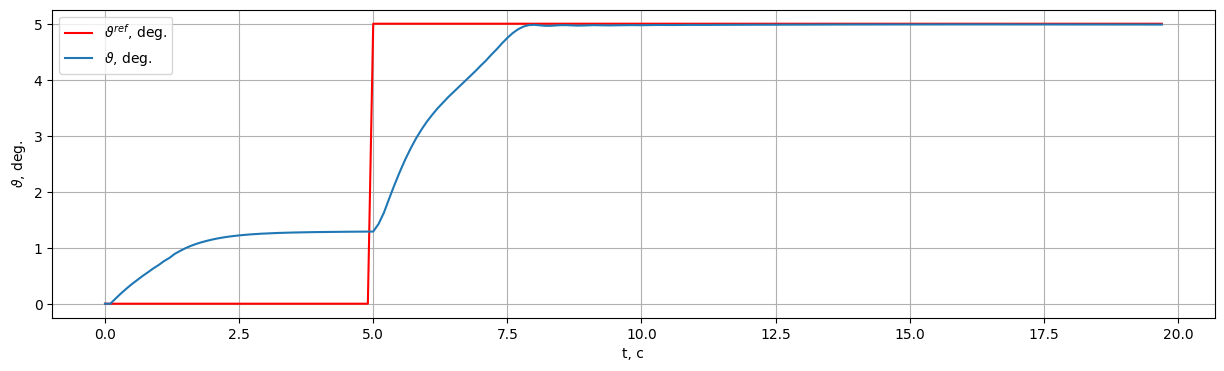

In [5]:
# Plot theta (pitch angle) tracking (last sampled reference)
ref = env.unwrapped.reference_signal[0]
print("Last reference kind:", getattr(env, "last_kind", "unknown"))
env.unwrapped.model.plot_transient_process('theta', tps, ref, to_deg=True, figsize=(15,4))

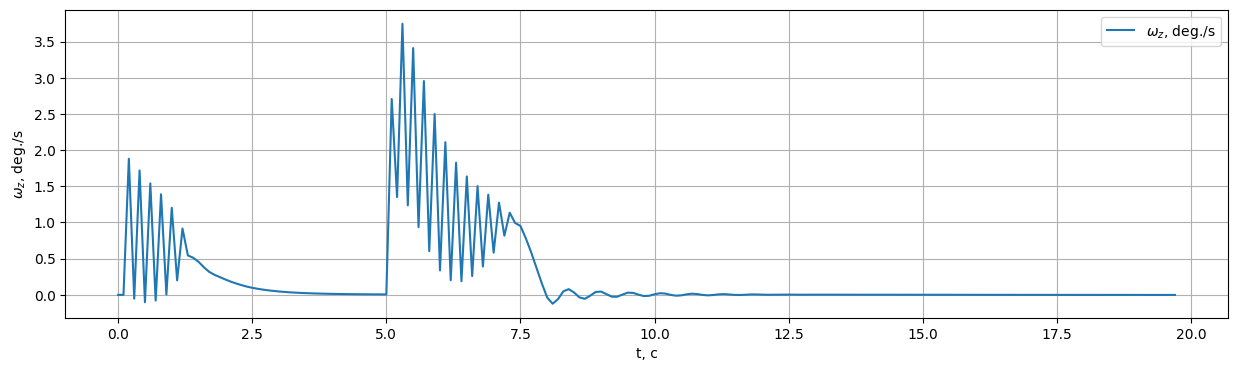

In [6]:
# Plot pitch rate (q)
env.unwrapped.model.plot_state(state_name='q', time=tps, to_deg=True, figsize=(15,4))


/home/mr8bit/Projects/TensorAeroSpace/tensoraerospace/aerospacemodel/base.py:388: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


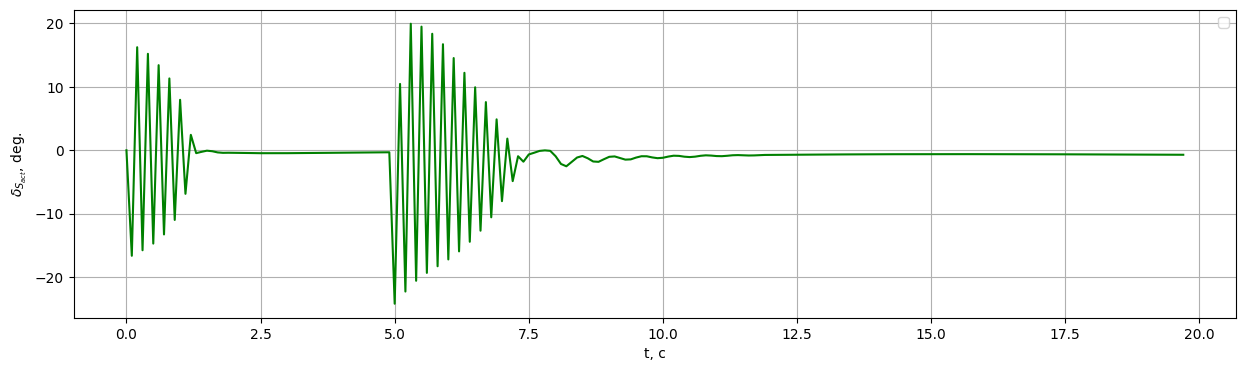

In [7]:
# Plot elevator control
env.unwrapped.model.plot_control(control_name='ele', time=tps, to_deg=True, figsize=(15,4))


In [16]:
agent.save("./ppo_b747_improved")

In [12]:
# Load checkpoint (best if available) and continue/evaluate
from pathlib import Path


def pick_checkpoint_dir(
    preferred: str = "./ppo_b747_improved_best",
    fallback_root: str = "./ppo_b747_improved",
) -> Path:
    preferred_p = Path(preferred)
    if preferred_p.exists() and (preferred_p / "config.json").exists():
        return preferred_p

    root = Path(fallback_root)
    if root.exists() and root.is_dir():
        # pick newest subdir that looks like a saved PPO folder
        subdirs = sorted(
            [p for p in root.iterdir() if p.is_dir()],
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
        for p in subdirs:
            if (p / "config.json").exists():
                return p

    raise FileNotFoundError(
        f"No checkpoint found. Tried {preferred_p.resolve()} and {root.resolve()}/*/config.json"
    )


ckpt_dir = pick_checkpoint_dir()
print("Loading checkpoint from:", ckpt_dir.resolve())
agent = PPO.from_pretrained(str(ckpt_dir))
print("Loaded agent. best_reward:", getattr(agent, "best_reward", None))



Loading checkpoint from: /home/mr8bit/Projects/TensorAeroSpace/example/comparison/ppo_b747_improved_best
Loaded agent. best_reward: -inf



Benchmark metrics:
{'overshoot': 0.9753099240391805, 'settling_time': 1.1, 'damping_degree': 0.002948721765771156, 'static_error': -0.012505547731548106, 'rise_time': 1.0, 'peak_time': 1.4000000000000001, 'maximum_deviation': 3.6248643757851546, 'iae': 23.584036566697982, 'ise': 56.84124809469584, 'itae': 22.58865830875923, 'oscillation_count': 1, 'steady_state_value': 5.0, 'performance_index': 31.967024546189865}


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: PPO checkpoint                                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                                                              ║
║ • Перерегулирование:         0.98%                    ║
║ • Вре

/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning:

WARN: env.amplitude_deg_range to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.amplitude_deg_range` for environment variables or `env.get_wrapper_attr('amplitude_deg_range')` that will search the reminding wrappers.

/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning:

WARN: env.step_time_sec_range to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.step_time_sec_range` for environment variables or `env.get_wrapper_attr('step_time_sec_range')` that will search the reminding wrappers.




Benchmark metrics:
{'overshoot': 3.4392497759046217, 'settling_time': 7.5, 'damping_degree': 0.06700405399875353, 'static_error': 0.2990875565808375, 'rise_time': 0.9, 'peak_time': 1.3, 'maximum_deviation': 5.878931233763228, 'iae': 85.33158491966051, 'ise': 169.74468202318863, 'itae': 500.57081655482403, 'oscillation_count': 1, 'steady_state_value': 7.1411667692332905, 'performance_index': 268.814049386386}


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: PPO checkpoint                                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                                                              ║
║ • Перерегулирование:         3.44%                    ║
║ • Время уст


Benchmark metrics:
{'overshoot': 24.02112249274874, 'settling_time': 0.8, 'damping_degree': 0.0, 'static_error': -0.7099902301140704, 'rise_time': 0.7000000000000001, 'peak_time': 10.700000000000001, 'maximum_deviation': 1.6342265341833948, 'iae': 121.40760649829454, 'ise': 88.79487865384301, 'itae': 1053.7564716207519, 'oscillation_count': 0, 'steady_state_value': 2.9832388549535027, 'performance_index': 461.82476460838774}


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: PPO checkpoint                                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                                                              ║
║ • Перерегулирование:        24.02%                  


Benchmark metrics:
{'overshoot': 31.8820022666835, 'settling_time': 0.7000000000000001, 'damping_degree': 0.0, 'static_error': -0.8231877005565829, 'rise_time': 0.6000000000000001, 'peak_time': 9.8, 'maximum_deviation': 1.1926880847151762, 'iae': 90.42612214612295, 'ise': 72.66270427112542, 'itae': 541.3017176163256, 'oscillation_count': 0, 'steady_state_value': 2.583153109765273, 'performance_index': 251.96216920831716}


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: PPO checkpoint                                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                                                              ║
║ • Перерегулирование:        31.88%                    ║


...


Benchmark metrics:
{'overshoot': 6.181348881985364, 'settling_time': 1.7000000000000002, 'damping_degree': 0.06447614531573098, 'static_error': 0.0748343977972965, 'rise_time': 0.9, 'peak_time': 1.4000000000000001, 'maximum_deviation': 7.064337326779773, 'iae': 70.53470938669102, 'ise': 243.00167191384008, 'itae': 198.68581172722003, 'oscillation_count': 1, 'steady_state_value': 8.418174364876702, 'performance_index': 177.9112632328211}


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: PPO checkpoint                                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                                                              ║
║ • Перерегулирование:         6.18%      


Benchmark metrics:
{'overshoot': 5.384735031707731, 'settling_time': 1.5, 'damping_degree': 0.07916215738668175, 'static_error': 0.2273836061918928, 'rise_time': 0.9, 'peak_time': 1.3, 'maximum_deviation': 6.288035900622869, 'iae': 70.31148487071744, 'ise': 190.30998859756116, 'itae': 246.4337499742995, 'oscillation_count': 1, 'steady_state_value': 7.6732034701123855, 'performance_index': 175.77444243508583}


╔══════════════════════════════════════════════════════════════╗
║                    ОТЧЕТ О КАЧЕСТВЕ УПРАВЛЕНИЯ               ║
╠══════════════════════════════════════════════════════════════╣
║ Система: PPO checkpoint                                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 📊 ОСНОВНЫЕ ПОКАЗАТЕЛИ КАЧЕСТВА:                            ║
║                                                              ║
║ • Перерегулирование:         5.38%                    ║
║ • Время уст

,amp_deg,step_time_s,overshoot,settling_time,static_error,oscillation_count,performance_index
0,7.141167,1.484389,3.439250,7.5,0.299088,1,268.814049
1,2.983239,2.659346,24.021122,0.8,-0.709990,0,461.824765
2,2.583153,8.308851,31.882002,0.7,-0.823188,0,251.962169
3,9.310105,3.489170,7.847163,2.0,-0.205232,1,218.819552
4,8.377791,9.009034,6.956555,1.8,0.130122,0,147.413674
5,5.616734,3.204681,-1.805782,1.1,0.154978,1,124.454908
6,8.418174,2.923867,6.181349,1.7,0.074834,1,177.911263
7,7.673203,6.669462,5.384735,1.5,0.227384,1,175.774442



Summary:


,overshoot,settling_time,static_error,oscillation_count,performance_index
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,10.488299,2.137500,-0.106501,0.625000,228.371853
std,11.374824,2.217423,0.434382,0.517549,106.535909
min,-1.805782,0.700000,-0.823188,0.000000,124.454908
25%,4.898364,1.025000,-0.331422,0.000000,168.684250
50%,6.568952,1.600000,0.102478,1.000000,198.365408
75%,11.890653,1.850000,0.173079,1.000000,256.175139
max,31.882002,7.500000,0.299088,1.000000,461.824765


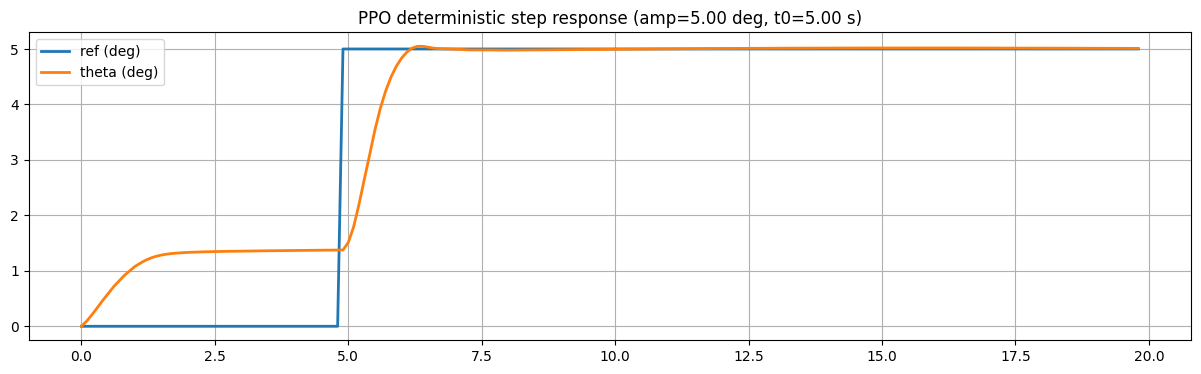

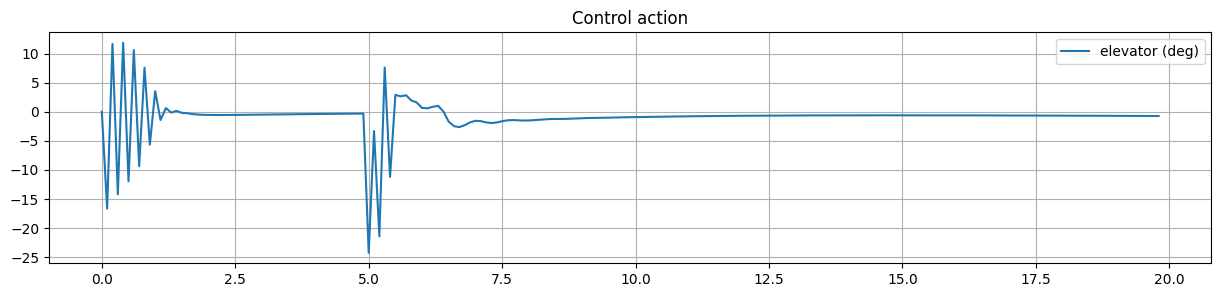

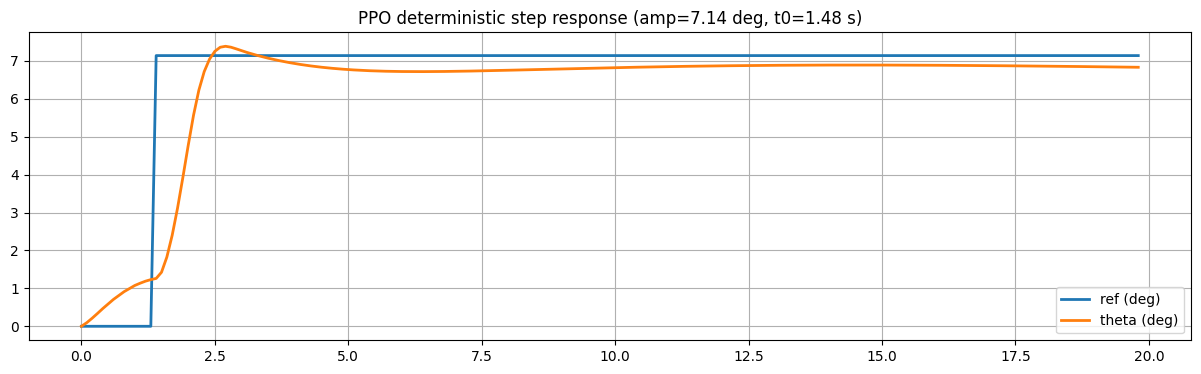

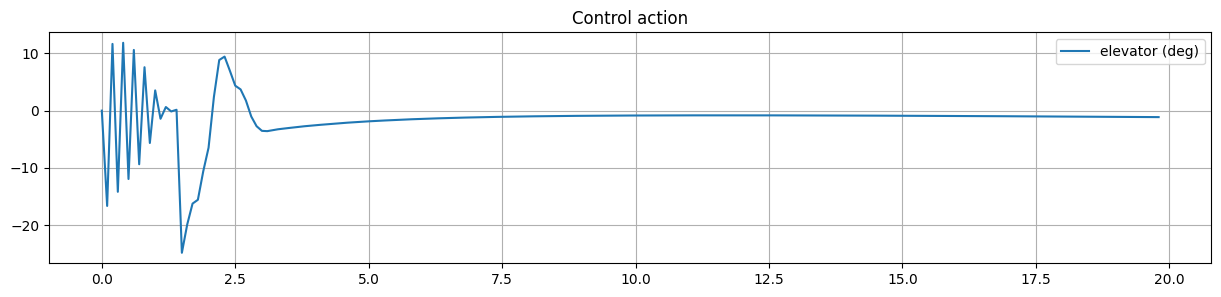

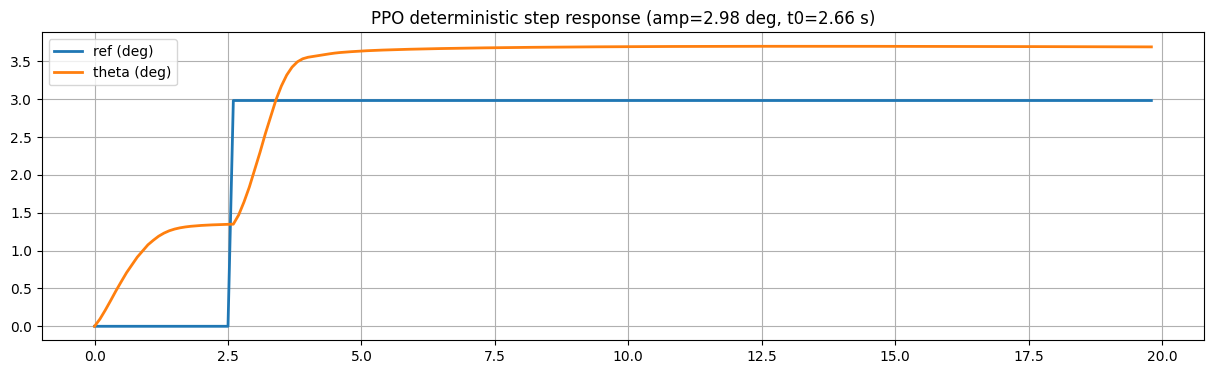

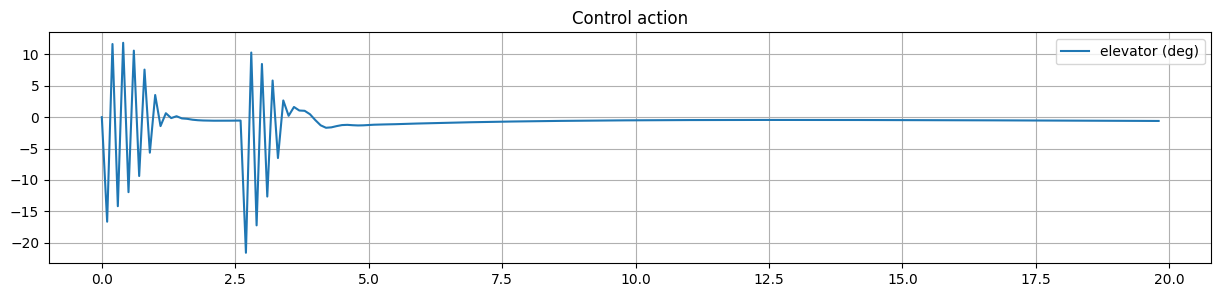

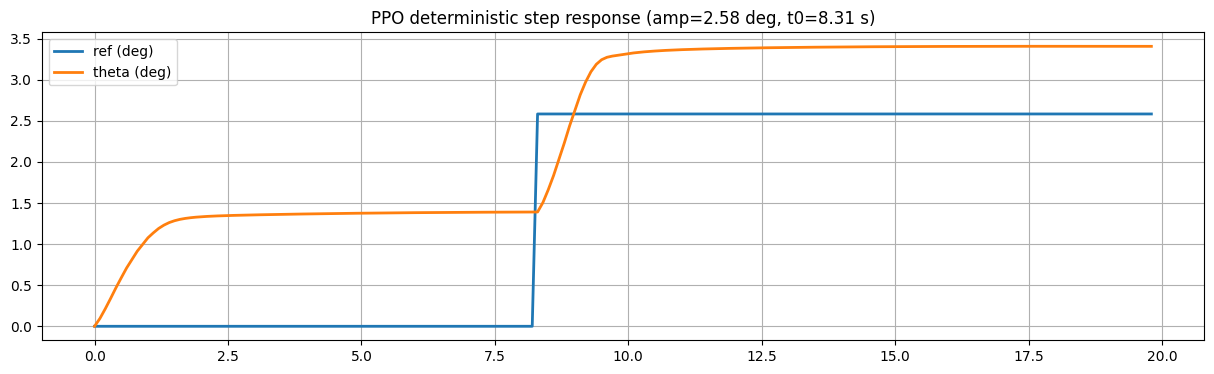

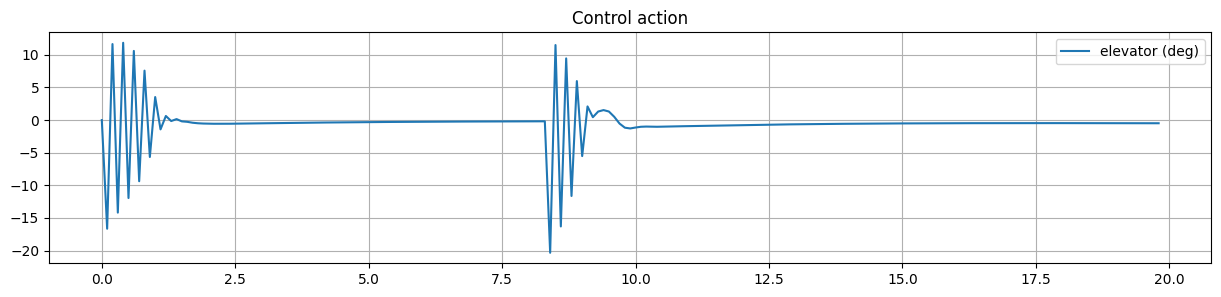

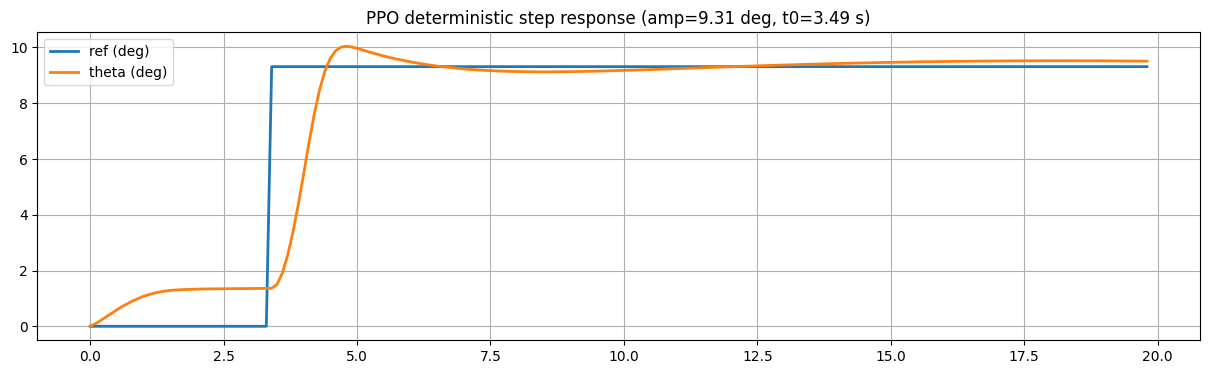

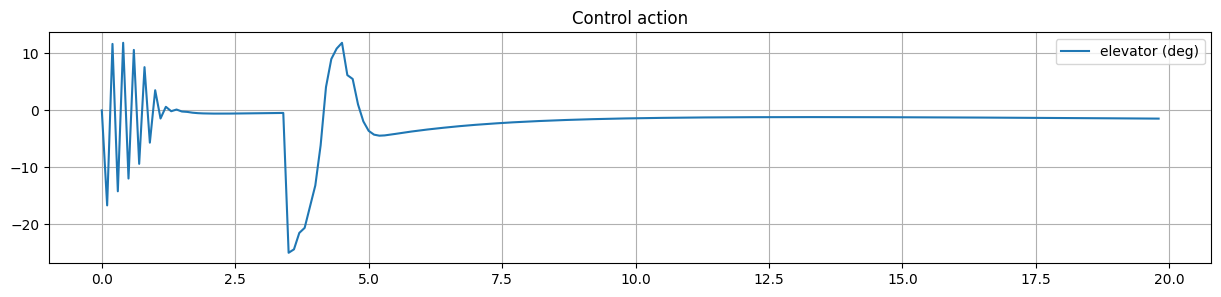

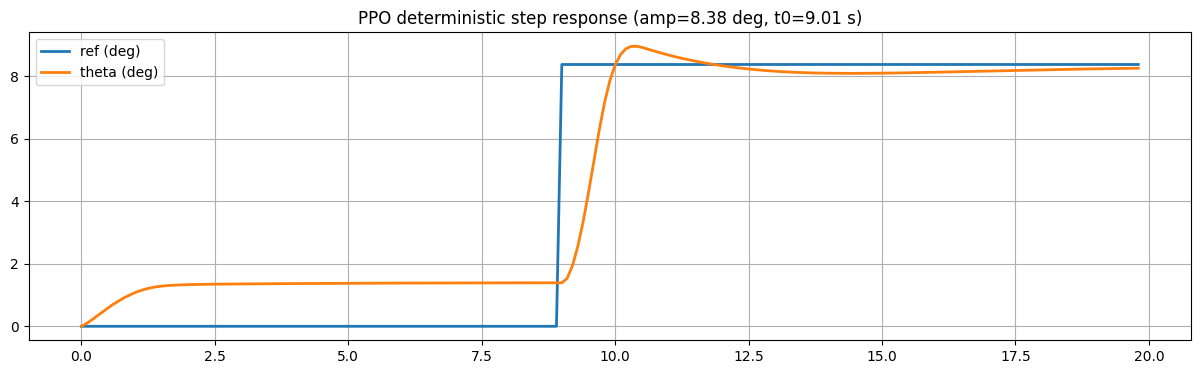

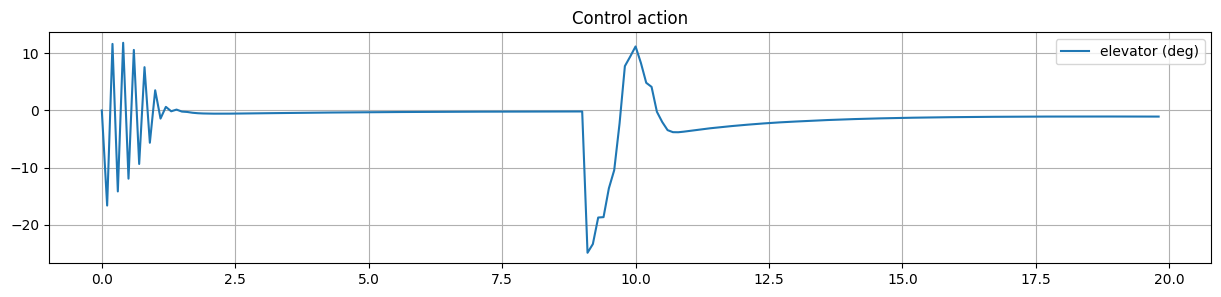

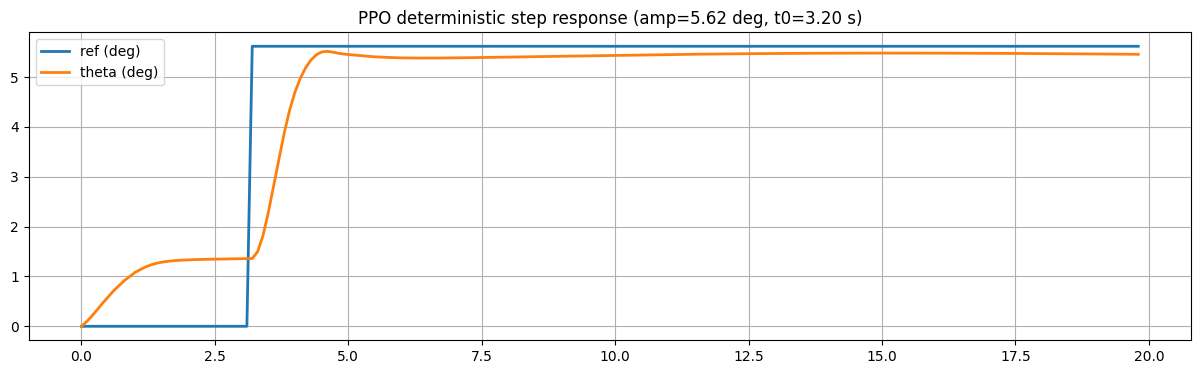

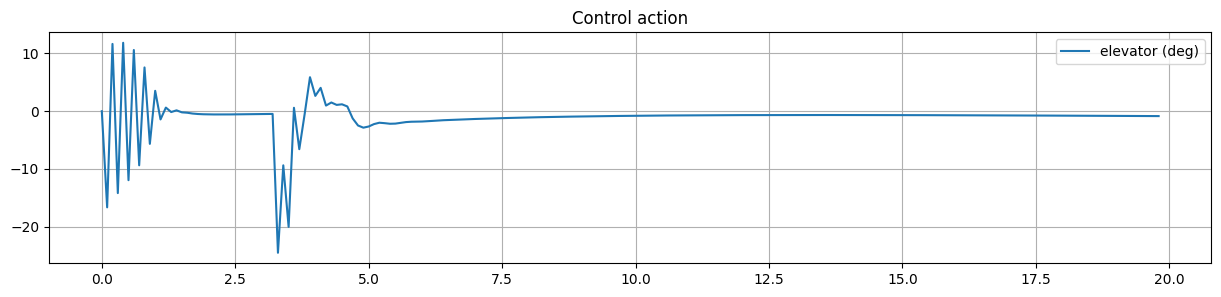

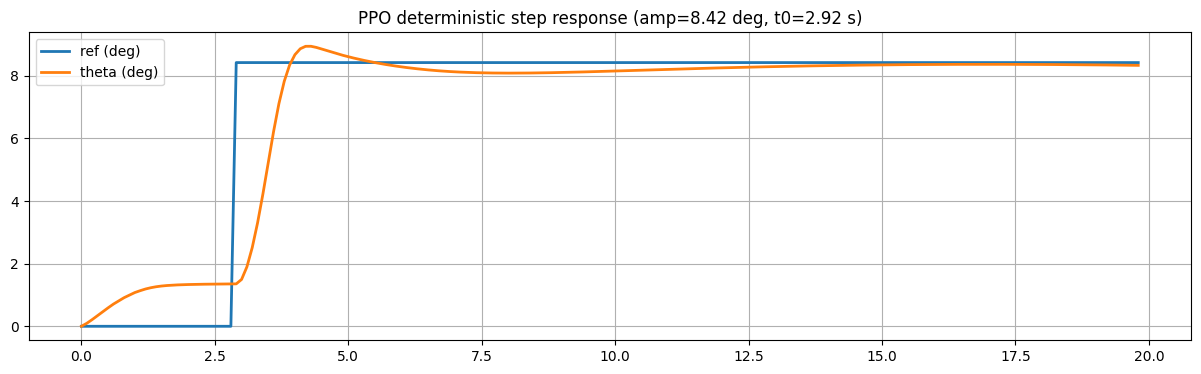

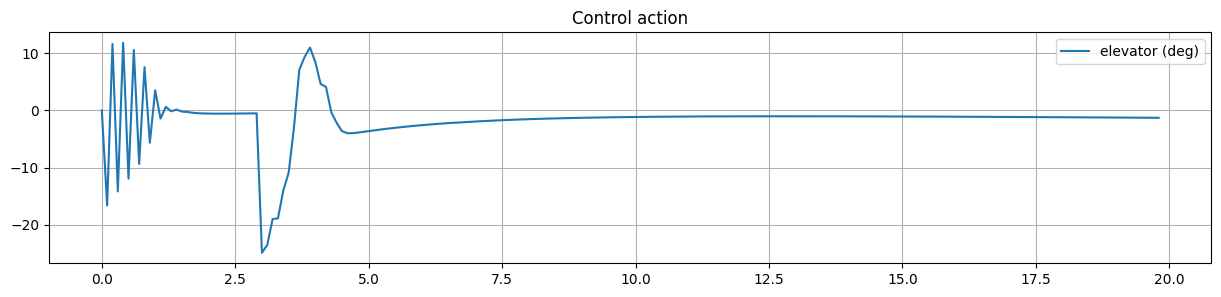

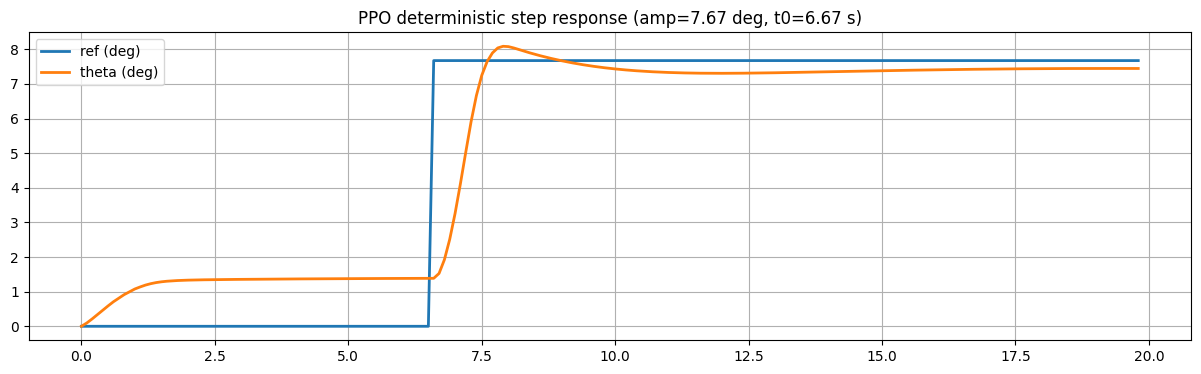

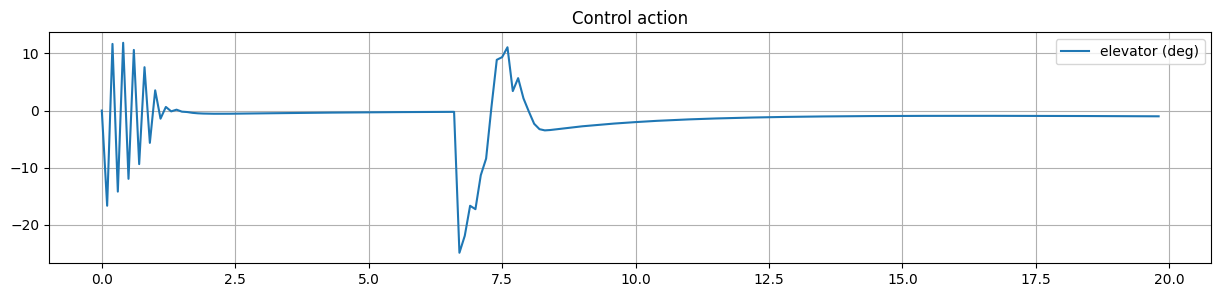

In [13]:
# Deterministic rollout + transient plot + benchmark
import matplotlib.pyplot as plt

from tensoraerospace.benchmark import ControlBenchmark


def run_step_episode(
    agent: PPO,
    *,
    amplitude_deg: float,
    step_time_sec: float,
) -> dict:
    ref = make_reference_signal(
        tps,
        "step",
        amplitude_deg=float(amplitude_deg),
        step_time_sec=float(step_time_sec),
    )

    eval_env = ImprovedB747Env(
        initial_state=init_state,
        reference_signal=ref,
        number_time_steps=number_time_steps,
        dt=dt,
        initial_elevator_deg=0.0,
    )

    obs, _ = eval_env.reset()

    theta_rad_hist: list[float] = []
    ref_rad_hist: list[float] = []
    elev_deg_hist: list[float] = []

    terminated = False
    truncated = False
    while not (terminated or truncated):
        _, mean_action, _ = agent.act(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(mean_action[0])

        theta_rad_hist.append(float(eval_env.state[eval_env._idx_theta]))
        idx = int(
            np.clip(
                eval_env.current_step,
                0,
                eval_env.reference_signal.shape[1] - 1,
            )
        )
        ref_rad_hist.append(float(eval_env.reference_signal[0, idx]))
        elev_deg_hist.append(
            float(eval_env.previous_action * eval_env.max_stabilizer_angle_deg)
        )

    theta_rad = np.asarray(theta_rad_hist)
    ref_rad = np.asarray(ref_rad_hist)
    elev_deg = np.asarray(elev_deg_hist)

    t_eval = tps[: len(theta_rad)]

    # Plots
    plt.figure(figsize=(15, 4))
    plt.plot(t_eval, np.rad2deg(ref_rad), label="ref (deg)", linewidth=2)
    plt.plot(t_eval, np.rad2deg(theta_rad), label="theta (deg)", linewidth=2)
    plt.grid(True)
    plt.legend()
    plt.title(
        f"PPO deterministic step response (amp={amplitude_deg:.2f} deg, t0={step_time_sec:.2f} s)"
    )

    plt.figure(figsize=(15, 3))
    plt.plot(t_eval, elev_deg, label="elevator (deg)")
    plt.grid(True)
    plt.legend()
    plt.title("Control action")

    # Benchmark
    bench = ControlBenchmark()
    control_deg = np.rad2deg(ref_rad)
    system_deg = np.rad2deg(theta_rad)

    metrics = bench.becnchmarking_one_step(
        control_signal=control_deg,
        system_signal=system_deg,
        signal_val=0.0,
        dt=dt,
    )

    print("\nBenchmark metrics:")
    print(metrics)

    print(
        "\n"
        + bench.generate_report(
            control_signal=control_deg,
            system_signal=system_deg,
            signal_val=0.0,
            dt=dt,
            system_name="PPO checkpoint",
        )
    )

    bench.plot(
        control_signal=control_deg,
        system_signal=system_deg,
        signal_val=0.0,
        dt=dt,
        tps=t_eval,
        title="PPO — benchmark",
    )

    return {
        "t": t_eval,
        "ref_deg": control_deg,
        "theta_deg": system_deg,
        "elev_deg": elev_deg,
        "metrics": metrics,
    }


# --- Single chosen scenario (edit these to validate specific cases)
res = run_step_episode(agent, amplitude_deg=5.0, step_time_sec=5.0)

# --- Optional: quick robustness check on multiple random (amp, step_time)
N_CASES = 8
rng = np.random.default_rng(123)
amp_lo, amp_hi = (1.0, 10.0)
st_lo, st_hi = (1.0, 10.0)
if hasattr(env, "amplitude_deg_range"):
    amp_lo, amp_hi = env.amplitude_deg_range
if hasattr(env, "step_time_sec_range"):
    st_lo, st_hi = env.step_time_sec_range

bench = ControlBenchmark()
rows = []
for i in range(N_CASES):
    amp = float(rng.uniform(amp_lo, amp_hi))
    st = float(rng.uniform(st_lo, st_hi))
    out = run_step_episode(agent, amplitude_deg=amp, step_time_sec=st)
    m = out["metrics"].copy()
    m.update({"amp_deg": amp, "step_time_s": st})
    rows.append(m)

try:
    import pandas as pd

    df = pd.DataFrame(rows)
    display(df[["amp_deg", "step_time_s", "overshoot", "settling_time", "static_error", "oscillation_count", "performance_index"]])
    print("\nSummary:")
    display(df[["overshoot", "settling_time", "static_error", "oscillation_count", "performance_index"]].describe())
except Exception:
    print("\nRobustness metrics (first 3):")
    print(rows[:3])

